# Plot the supplementary figures for revision1 of paper2
2025.9.22
Mu-Ting Chien

In [11]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [82]:
DIR                    = '/barnes-engr-scratch1/c832572266/'
file_dir_obs_ace2      = DIR + 'data_output/ace2/obs_compare_with_ace2/'
file_dir_ace2          = DIR + 'data_output/ace2/ace2_output/10yr/'
file_dir_ace2_100yr    = DIR + 'data_output/ace2/ace2_output/repeat_2001-2010/'
fig_dir                = DIR + 'figure/paper2_fig/revision1/'
os.makedirs(fig_dir, exist_ok=True)
fig_dir_supplement = fig_dir + 'supplement/'
os.makedirs(fig_dir_supplement, exist_ok=True)

vname_list = list(['TCGI','col_rh','abs_vor_clip','shear','relsst'])#,'sst'])
vname_list2 = list(['\u0394 TC','col RH','abs vor','shear','relsst'])
calc_daily = 1

lag = 32
lags = np.arange(-lag, lag+1)/4
calc_daily = 1
if calc_daily == 1:
    lags_daily = np.arange(-lag/4+1, lag/4)
unit_list = list(['#/yr','%','10$^{-7}$1/s','m/s','K'])
daily = list(['','_daily'])
lag_day = int(lag/4)

In [63]:
print(lags_daily)

[-7. -6. -5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.  6.  7.]


# Load TC anomaly

In [25]:
data = np.load(file_dir_ace2_100yr + 'TCgenesis_lag_kwcrest_TCano_daily.npz')
bin_center = data['bin_center']
TC_obs_ano = data['TC_obs_ano']
TC_ace2_ano = data['TC_ace2_ano']

# Load each environmental factor lagging KW

In [21]:
# Load ace2 data
data                           = np.load(file_dir_ace2_100yr+'TCGI_KW_lag_regression_basin_ace2_100yr.npz')
TCGI_lag_kw_basin_ace2         = data['TCGI_lag_kw_basin_ace2']
shear_lag_kw_basin_ace2        = data['shear_lag_kw_basin_ace2']
col_rh_lag_kw_basin_ace2       = data['col_rh_lag_kw_basin_ace2']
abs_vor_clip_lag_kw_basin_ace2 = data['abs_vor_clip_lag_kw_basin_ace2']
relsst_lag_kw_basin_ace2       = data['relsst_lag_kw_basin_ace2']
lags                           = data['lags']
basin_list                     = data['basin_list']
nbasin                         = len(basin_list)

In [13]:
# Load obs data
data                           = np.load(file_dir_obs_ace2+'TCGI_KW_lag_regression_basin_era5.npz')
TCGI_lag_kw_basin_era5         = data['TCGI_lag_kw_basin_era5']
shear_lag_kw_basin_era5        = data['shear_lag_kw_basin_era5']
col_rh_lag_kw_basin_era5       = data['col_rh_lag_kw_basin_era5']
abs_vor_clip_lag_kw_basin_era5 = data['abs_vor_clip_lag_kw_basin_era5']
relsst_lag_kw_basin_era5       = data['relsst_lag_kw_basin_era5']

In [26]:
print(basin_list)

['NI' 'NWPAC' 'NEPAC' 'NATL' 'SI' 'SPAC']


In [57]:
ibasin_list = np.array([4, 0, 5, 1])

# Plot TC anomaly and env condition

In [29]:
print(np.shape(lags_tmp))

(15,)


Change vor unit
-1.9001471143210291 2.5260866686737553


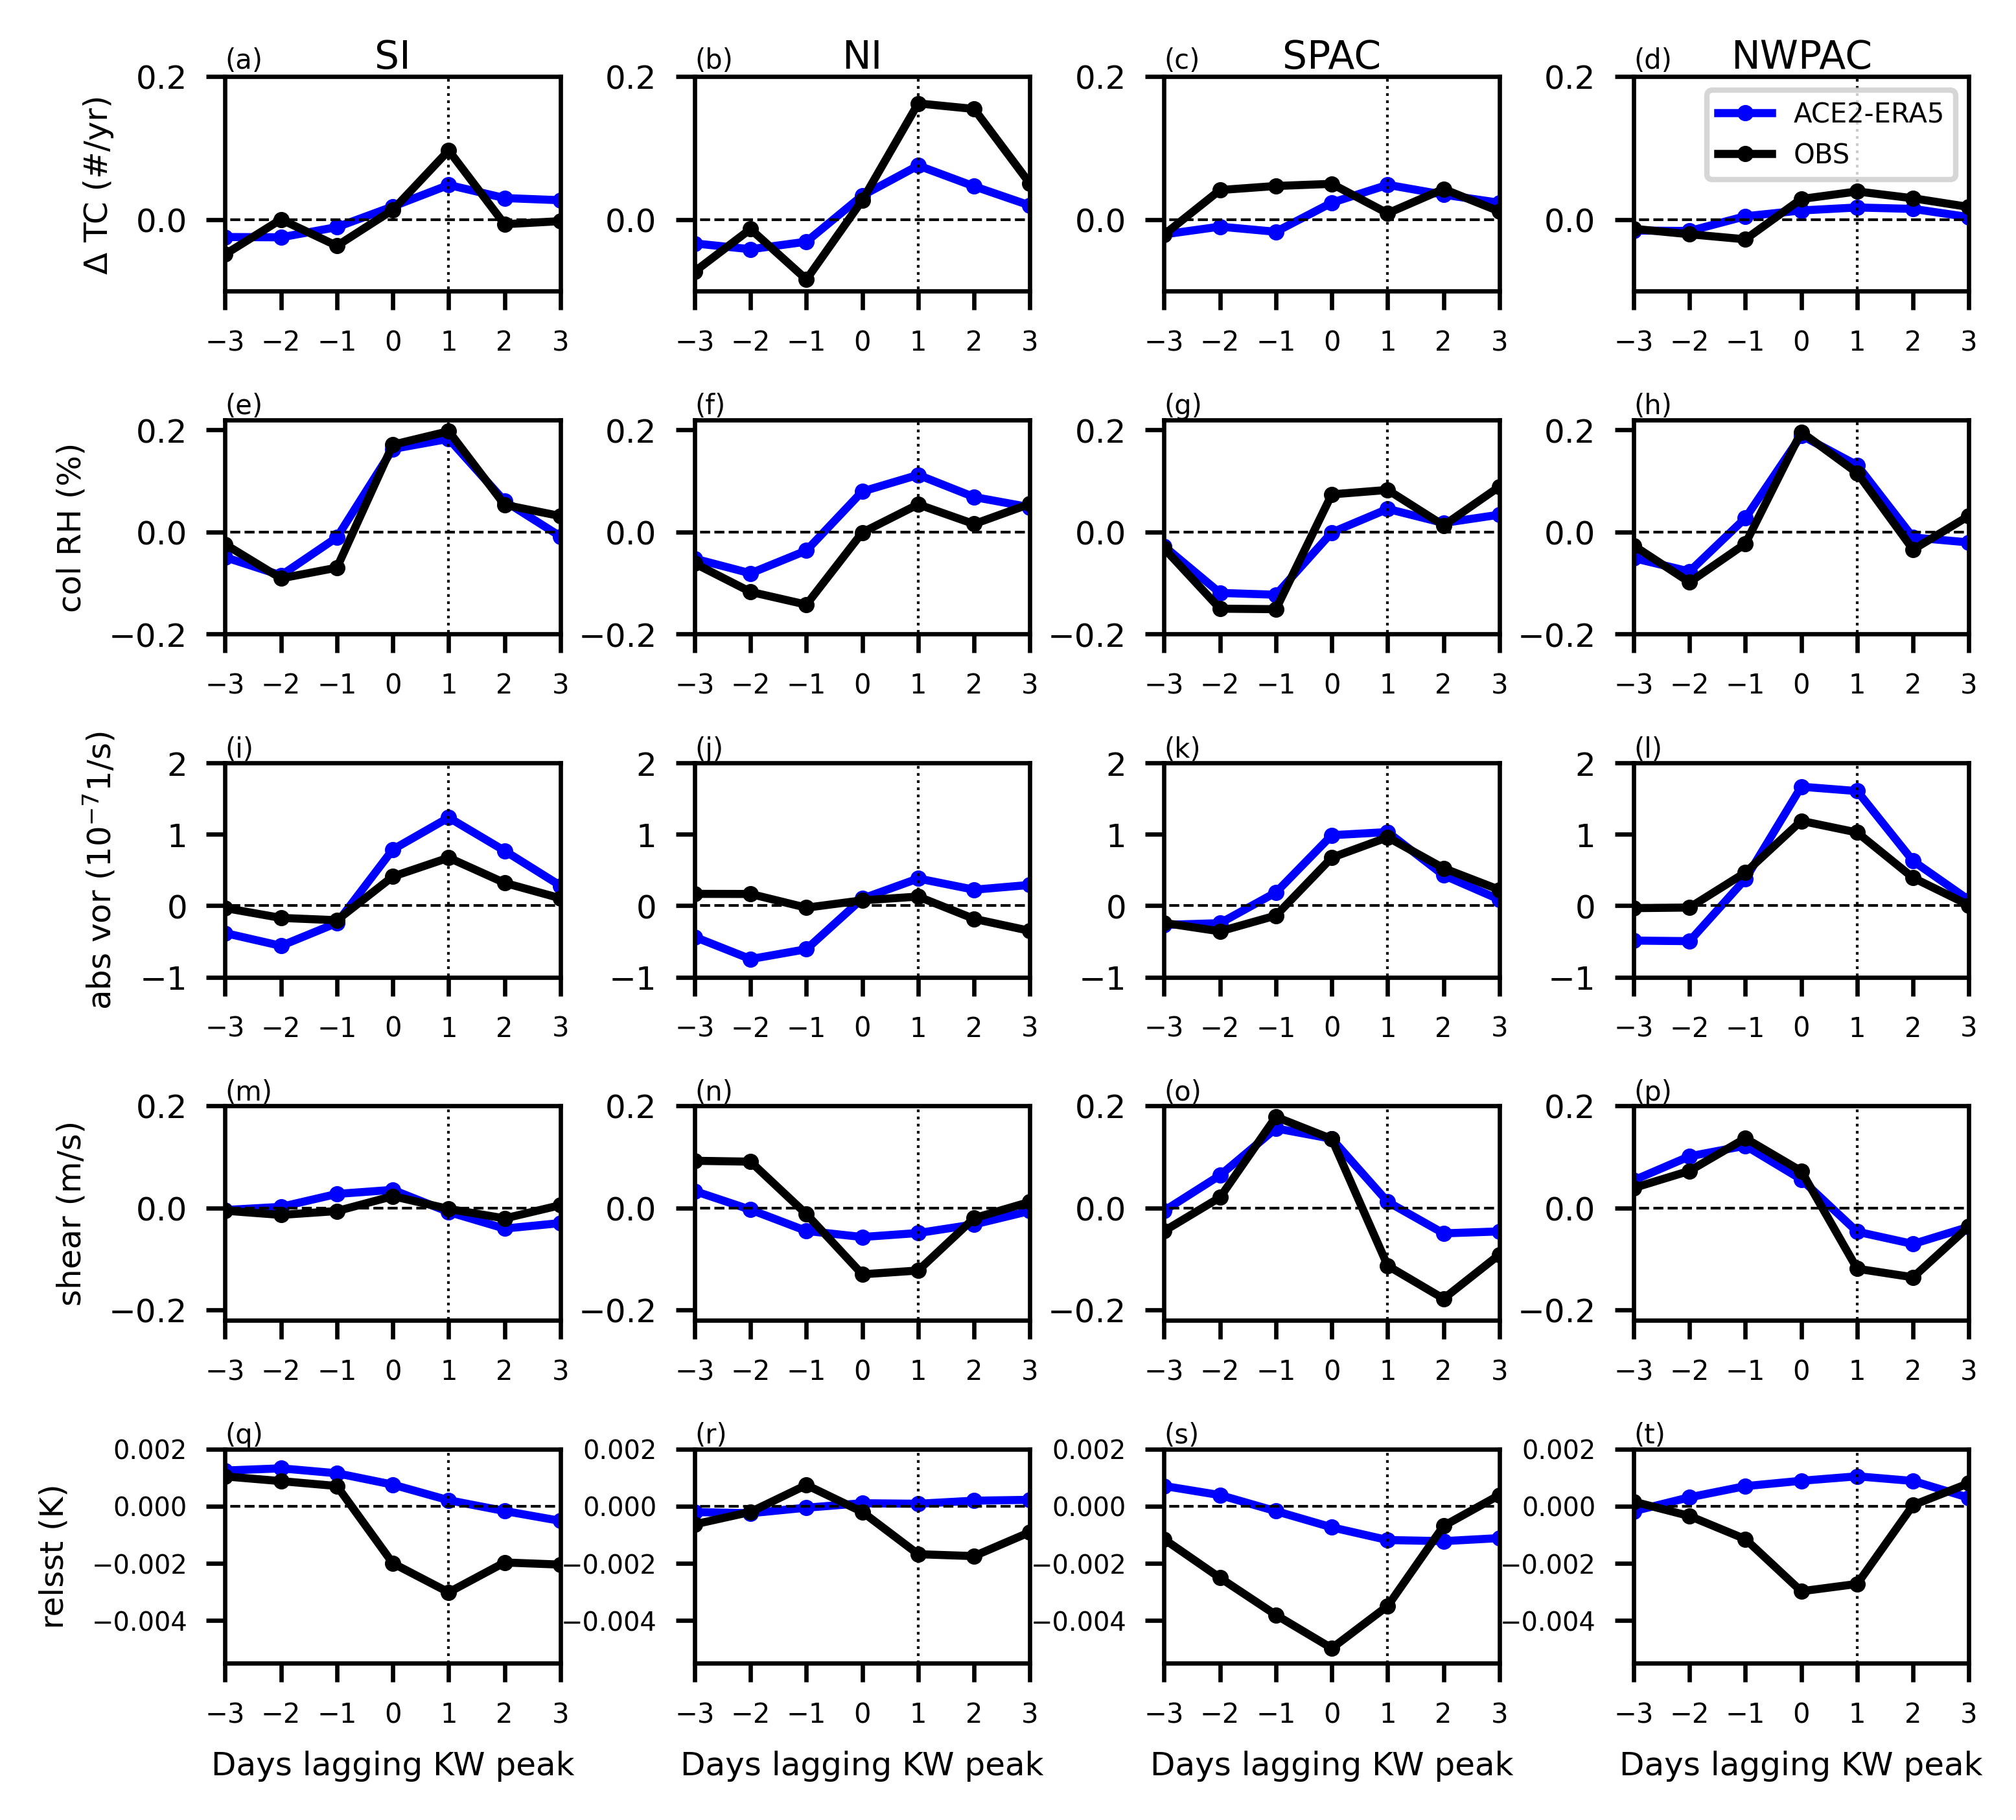

In [88]:
label_list = list(['(a)','(b)','(c)','(d)',\
    '(e)','(f)','(g)','(h)',\
        '(i)','(j)','(k)','(l)',\
            '(m)','(n)','(o)','(p)',\
                '(q)','(r)','(s)','(t)'])

font = 5

fig_name = 'Fig.S_KW_lag_regression_TC_env.png'
fig = plt.subplots(5,4,figsize=(6.5, 6),dpi=600)
plt.subplots_adjust(left=0.3,right=0.99,top=0.88,bottom=0.2, wspace=0.4, hspace=0.6)
plt.rcParams.update({'font.size': 6})

for iv in range(0, np.size(vname_list)):

    KW_composite_ace2 = globals()[vname_list[iv]+'_lag_kw_basin_ace2']
    KW_composite_era5 = globals()[vname_list[iv]+'_lag_kw_basin_era5']

    if calc_daily == 1:
        # Calculate daily average
        for it in range(0, lag_day*2-1):
            if it == 0:
                KW_composite_ace2_daily = np.empty([lag_day*2-1, nbasin])
                KW_composite_era5_daily = np.empty([lag_day*2-1, nbasin])
            KW_composite_ace2_daily[it, :] = np.nanmean(KW_composite_ace2[it*4+2:(it+1)*4+2+1, :], 0)
            KW_composite_era5_daily[it, :] = np.nanmean(KW_composite_era5[it*4+2:(it+1)*4+2+1, :], 0)

        if iv == 2:
            KW_composite_ace2_daily = KW_composite_ace2_daily*10**7
            KW_composite_era5_daily = KW_composite_era5_daily*10**7
            print('Change vor unit')
            print(np.min(KW_composite_ace2_daily), np.max(KW_composite_ace2_daily))

        lags_tmp = lags_daily
    else:
        lags_tmp = lags


    for i in range(0, 4):# Which basin nbasin):
        iplt = 4*iv+i
        plt.subplot(5, 4, iplt+1)
        
        ibasin = ibasin_list[i]
        if iv !=0:
            KW_composite_ace2_ano = KW_composite_ace2_daily[:,ibasin] - np.nanmean(KW_composite_ace2_daily[:,ibasin])
            KW_composite_era5_ano = KW_composite_era5_daily[:,ibasin] - np.nanmean(KW_composite_era5_daily[:,ibasin])
        else:
            KW_composite_ace2_ano = TC_ace2_ano[:,ibasin]
            KW_composite_era5_ano = TC_obs_ano[:,ibasin]
           
        zero = np.zeros([np.size(lags_tmp)])
        if iv != 0:
            plt.plot(lags_tmp, KW_composite_ace2_ano, 'b-o',markersize=2)
            plt.plot(lags_tmp, KW_composite_era5_ano, 'k-o',markersize=2)
        else:
            plt.plot(bin_center, KW_composite_ace2_ano, 'b-o',markersize=2)
            plt.plot(bin_center, KW_composite_era5_ano, 'k-o',markersize=2)
        if i == 3 and iv == 0:
            plt.legend(['ACE2-ERA5','OBS'], fontsize=5)
        plt.plot(lags_tmp,zero,'k--', linewidth=0.5)
        plt.xlim([-3, 3])
        plt.xticks(np.arange(-3,4), fontsize=5)
        if iv == 4:
            plt.xlabel('Days lagging KW peak')
        if i == 0:
            plt.ylabel(vname_list2[iv]+' ('+unit_list[iv]+')')

        if iv == 0:
            plt.title(basin_list[ibasin])
        plt.title(label_list[iplt], pad=0.1, loc='left',fontsize=font)

        plt.plot([1,1],[-100,100],'k', linestyle=':', linewidth=0.5)

        if iv == 0:
            plt.ylim([-0.1,0.2])
        elif iv == 1:
            plt.ylim([-0.2, 0.22])
        elif iv == 2:
            plt.ylim([-1, 2])
        elif iv == 3:
            plt.ylim([-0.22, 0.2])
        elif iv == 4:
            plt.ylim([-0.0055, 0.002])
            plt.yticks(np.arange(-0.004,0.004,0.002), fontsize=4.8)
        #if i == 1:
        #    plt.suptitle('KW lag-regression '+vname_list[iv]+' (20S-20N)')
        
        

plt.savefig(fig_dir+fig_name,format='png', dpi=600)
plt.show()
plt.close()